# Digital Modulation

This interactive notebook demonstrates digital modulation types using Python.

## Learning Outcomes

* Student can explain the properties of a wave: amplitude, frequency, and phase shift.
* Student can explain and implement amplitude shift keying
* Student can explain and implement phase shift keying
* Student can explain and implement quadrature amplitude modulation
* Student can examine a constellation diagram an determine how many symbols are supported and how many amplitudes and phase shifts are used

## Carrier Waves

Modulation is a way of encoding information in a wave.
In our case we typically use electromagnetic waves centered on a particular frequency.
We call our starting wave a carrier wave.
In the real of wireless networks the carrier wave will typically be in the GHz range, but for this example we will stick to 800 Hz so that we can listen to how the modulations sound.

The way we represent waves in the digital world is by sampling them at a particular interval.
The amount of samples you take per second is called the _sample rate_.
The amount of time between samples is called the _sample period_.
By sampling over a period of time you can get a [reasonable digital representation](https://en.wikipedia.org/wiki/Nyquist_frequency) of an analog waveform.

The following code block sets up our sample rate, sample period, how many samples we use to represent a symbol, and what the bits of our message are going to be:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio

SAMPLE_RATE = 9600
SAMPLE_PERIOD = 1 / SAMPLE_RATE
SAMPLES_PER_SYMBOL = 24
FREQUENCY = 800
MESSAGE = [1, 1, 1, 1, 0, 1, 1, 0]

Take a look at the following loop.
It iterates over every bit in the message and for each bit in the message it generates `SAMPLES_PER_SYMBOL` samples.
Right now our waveform has a steady frequency, amplitude, and phase shift because it's just the base, carrier wave.

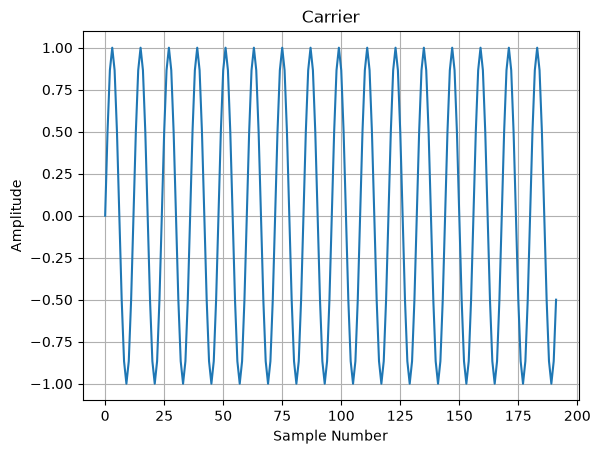

In [2]:
amplitude = 1
phase_shift = 0
time = 0
samples = []
for bit in MESSAGE:
    for i in range(SAMPLES_PER_SYMBOL):
        value = amplitude * np.sin(2 * np.pi * FREQUENCY * time + phase_shift)
        samples.append(value)
        time += SAMPLE_PERIOD

plt.plot(range(len(samples)), samples)
plt.title("Carrier")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

If you're curious as to what this would sound like, I've generated a second of a 440 Hz sine wave below.
I didn't use the actual samples we generated because our signal takes such a short amount of time you wouldn't hear anything.

In [3]:
t = np.linspace(0, 1, SAMPLE_RATE * 1)
audio_data = np.sin(2 * np.pi * FREQUENCY * t)
Audio(audio_data, rate=SAMPLE_RATE, autoplay=False)

## Amplitude Shift Keying

Now let's generate another wave based on the carrier wave, but this time we'll modulate the amplitude.
If we're encoding a zero the amplitude will be 1 and if we're encoding a 1 the amplitude will be 2.

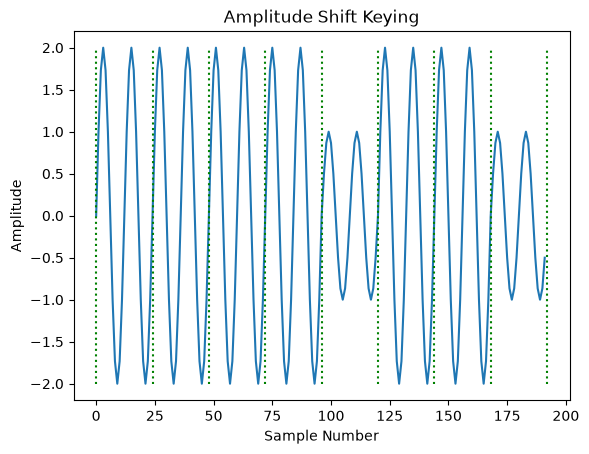

In [4]:
phase_shift = 0
time = 0
samples = []
for bit in MESSAGE:
    if bit == 0:
        amplitude = 1
    else:
        amplitude = 2
    for i in range(SAMPLES_PER_SYMBOL):
        value = amplitude * np.sin(2 * np.pi * FREQUENCY * time + phase_shift)
        samples.append(value)
        time += SAMPLE_PERIOD

plt.plot(range(len(samples)), samples)
plt.title("Amplitude Shift Keying")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.vlines(x=range(0,SAMPLES_PER_SYMBOL*len(MESSAGE)+1, SAMPLES_PER_SYMBOL), ymin=-2, ymax=2, colors='green', linestyles='dotted')
plt.show()

I've added a vertical line at each bit transition so that hopefully you can see the encoded signal.

<div class="alert alert-block alert-warning">
    <b>Warning:</b>
    While this looks simple, in actuality the devil is in the details.
    The constants have been picked to make things work out well.
    Our 800 Hz sine wave takes up 12 samples per cycle at our sample rate (9600/800).
    There's a zero crossing every 6 samples so multiples of 6 can be used for the samples per symbol without causing discontinuities in the ASK graph above.
    Discontinuities are big jumps in the waveform that result in the signal occupying more bandwidth.
</div>

Remember that ASK requires the receiver to measure signal gain to determine what the shifts are.
Their will be attenuation as the signal is transmitted and the receiver will have to see a few level shifts to beging decoding your message.
The more levels there are, the tougher it can be to make that determination.

Again, our signal is too short to listen to, but if we loop it 50 times we can get a feel for was ASK sounds like:

In [5]:
audio_data = []
for i in range(50):
    audio_data += samples
Audio(audio_data, rate=SAMPLE_RATE, autoplay=False)

## Phase Shift Keying

Now let's generate a waveform where the carrier frequencies phases is shifted by $\pi$ if we're encoding a 0 and $0$ if we're encoding a 1.

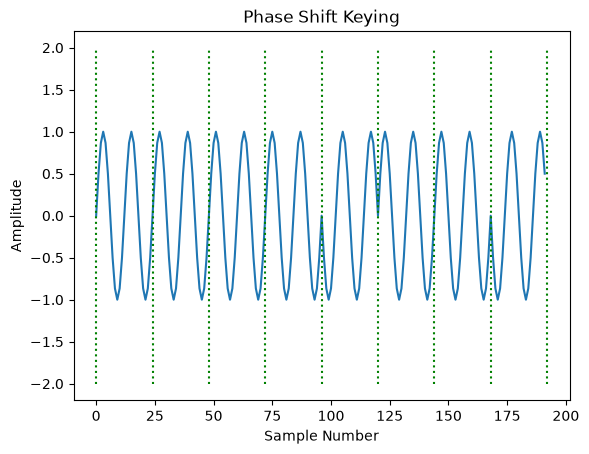

In [6]:
amplitude = 1
time = 0
samples = []
for bit in MESSAGE:
    if bit == 0:
        phase_shift = np.pi
    else:
        phase_shift = 0
    for i in range(SAMPLES_PER_SYMBOL):
        value = amplitude * np.sin(2 * np.pi * FREQUENCY * time + phase_shift)
        samples.append(value)
        time += SAMPLE_PERIOD

plt.plot(range(len(samples)), samples)
plt.title("Phase Shift Keying")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.vlines(x=range(0,SAMPLES_PER_SYMBOL*len(MESSAGE)+1, SAMPLES_PER_SYMBOL), ymin=-2, ymax=2, colors='green', linestyles='dotted')
plt.show()

This particular type of modulation is called binary phase shift keying or BPSK.
You may look at this and say, "well that's a whole lot of discontinuities!"
You'd be right and as-is this signal would occupy _a lot_ of bandwidth.
You'd need to tighten it up with a filter _after_ you modulate it.
While PSK may look awful in the time domain to the human eye, it's actually relatively easy to demodulate it with a computer.

Another common PSK scheme is Quadrature Phase Shift Keying.
In QPSK four phases are used.

Here's an example of what this waveform would sound like (again looped 50 times):

In [7]:
audio_data = []
for i in range(50):
    audio_data += samples
Audio(audio_data, rate=SAMPLE_RATE, autoplay=False)

## Quadrature Amplitude Modulation

So far, our symbols have been bits.
That is we encode either a one or a zero.
What if we could combine amplitude and phase to encode multiple bits?
That's what QAM is.

Before we jump into QAM, we need to understand a constellation diagram.

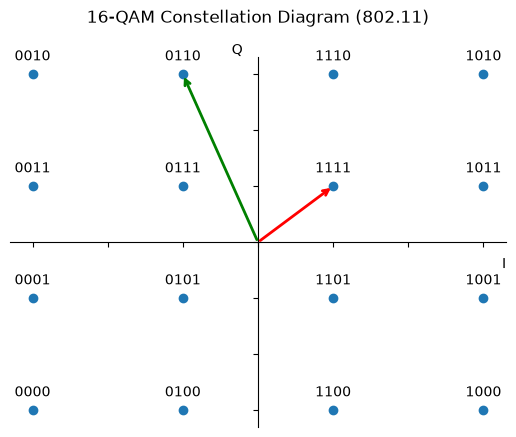

In [8]:
x = [-3, -1, 1, 3, -3, -1, 1, 3, -3, -1,  1,  3, -3, -1,  1,  3] 
y = [ 3,  3, 3, 3,  1,  1, 1, 1, -1, -1, -1, -1, -3, -3, -3, -3]
labels = [
    "0010", "0110", "1110", "1010",
    "0011", "0111", "1111", "1011",
    "0001", "0101", "1101", "1001",
    "0000", "0100", "1100", "1000"
]

fig, ax = plt.subplots()

ax.scatter(x, y)
for i, txt in enumerate(labels):
    ax.annotate(txt, (x[i], y[i]), textcoords="offset points", ha='center', xytext=(0, 10))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

ax.set_xticklabels([])
ax.set_xlabel("I", loc="right")
ax.set_yticklabels([])
ax.set_ylabel("Q", loc="top", rotation=0)

ax.set_title("16-QAM Constellation Diagram (802.11)", pad=25)

ax.annotate("", xy=(1,1), xytext=(0,0), arrowprops=dict(arrowstyle="->", color="red", lw=2))
ax.annotate("", xy=(-1,3), xytext=(0,0), arrowprops=dict(arrowstyle="->", color="green", lw=2))

plt.show()

In the above diagram, each blue dot represents a symbol which can store 4 bits (there's 16 dots, hence 16-QAM).
They are plotted on a constellation or IQ diagram where _I_ is the x axis and _Q_ is the y axis.
_I_ stands for in-phase and it is the part of the signal that is in-phase with the refence (in our case a carrier wave).
_Q_ stands for quadrature and it is the part of the signal that is 90 outof phase with the reference.

The distance from a symbol to the center of the diagram is the amplitude used to send that symbol.
`1111` has a smaller amplitude that `0110`, the red arrow is smaller than the green arrow.
The phase for a symbol is the angle between a line drawn from the symbol to the origin.
You can see the red arrow makes an angle of 45 degrees with the _I_ axis, meaning the phase shift for `1111` is 45 degrees.
The green arrow makes an angle of 108 degrees with the _I_ axis, meaning the phase shift for `0110` is 108 degrees.

Now using 16-QAM we could send our `MESSAGE` bits by modulating a carrier wave by:
* amplitude=1.41, phase_shift=45° (1111)
* amplitude=3.16, phase_shift=108° (0110)

We've just increased the speed we send our message by a factor of four, but only having to send two symbols instead of 8 (as was the case with our ASK and PSK schemes)!

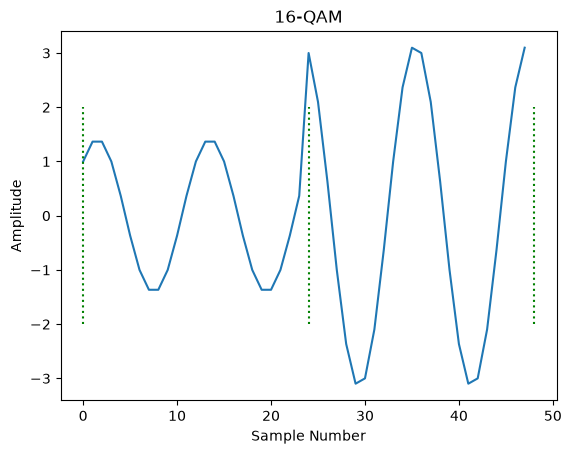

In [9]:
SYMBOLS = [0b1111, 0b0110]

time = 0
samples = []
for symbol in SYMBOLS:
    
    # These are the amplitudes and phases for the 16QAM 802.11-2020 standard
    # there's a more elegant way to do this, but this is the most obvious
    if symbol == 0b1011:
        amplitude = 3.162
        phase = 18.435
    elif symbol == 0b1010:
        amplitude = 4.243
        phase = 45
    elif symbol == 0b1111:
        amplitude = 1.414
        phase = 45
    elif symbol == 0b1110:
        amplitude = 3.162
        phase = 71.565
    elif symbol == 0b0110:
        amplitude = 3.162
        phase = 108.435
    elif symbol == 0b0010:
        amplitude = 4.343
        phase = 135
    elif symbol == 0b0111:
        amplitude = 1.414
        phase = 135
    elif symbol == 0b0011:
        amplitude = 3.162
        phase = 161.565
    elif symbol == 0b0001:
        amplitude = 3.162
        phase = 198.435
    elif symbol == 0b0000:
        amplitude = 4.243
        phase = 225
    elif symbol == 0b0101:
        amplitude = 1.414
        phase = 225
    elif symbol == 0b0100:
        amplitude = 3.162
        phase = 251.565
    elif symbol == 0b1100:
        amplitude = 3.162
        phase = 288.435
    elif symbol == 0b1000:
        amplitude = 4.243
        phase = 315
    elif symbol == 0b1101:
        amplitude = 1.414
        phase = 315
    elif symbol == 0b1001:
        amplitude = 3.162
        phase = 341.565

    phase_shift = phase / 360 * 2 * np.pi
    
    for i in range(SAMPLES_PER_SYMBOL):
        value = amplitude * np.sin(2 * np.pi * FREQUENCY * time + phase_shift)
        samples.append(value)
        time += SAMPLE_PERIOD

plt.plot(range(len(samples)), samples)
plt.title("16-QAM")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.vlines(x=range(0,SAMPLES_PER_SYMBOL*len(SYMBOLS)+1, SAMPLES_PER_SYMBOL), ymin=-2, ymax=2, colors='green', linestyles='dotted')
plt.show()

In [10]:
audio_data = []
for i in range(200):
    audio_data += samples
Audio(audio_data, rate=SAMPLE_RATE, autoplay=False)

## Wi-Fi 6

If you haven't asked it already, at this point you're probably wondering why this matters.
Well it turns out that the modulation you use (along with other factors) has a great effect on your channel capacity (how fast) and your signals resistance to noise.

Wi-Fi 6 (802.11ax) picks a Modulation and Coding Scheme (MCS) index based on the quality of the link between devices.
You should now be familiar with some of the modulation schemes in this table:

| MCS   | Modulation | Coding Rate | Bits/Symbol | Best Used For / Signal Quality                  |
| ----- | ---------- | ----------- | ----------- | ----------------------------------------------- |
| 0     | BPSK       | 1/2         | 0.5         | Extreme range, high interference, basic control |
| 1-2   | QPSK       | 1/2 to 3/4  | 1.0-1.5     | Weak signal, heavy walls/distance               |
| 3-4   | 16-QAM     | 1/2 to 3/4  | 2.0-3.0     | Moderate edge-of-coverage                       |
| 5-7   | 64-QAM     | 2/3 to 5/6  | 4.0-5.0     | Good average indoor connection                  |
| 8-9   | 256-QAM    | 3/4 to 5/6  | 6.0-6.67    | Strong signal near access point                 |
| 10-11 | 1024-QAM   | 3/4 to 5/6  | 7.5-8.33    | Maximum throughput, very high SNR (~41+ dB)     |

In this way a modern Wi-Fi network can 